You are a computer vision engineer at FreshTrack, a produce supply chain company. Warehouses receive mixed crates of fruit and need to automatically sort them by type, flag color defects (underripe or overripe), and count individual pieces before packing. Manual inspection is slow and inconsistent under variable warehouse lighting. Your job
is to build a CV pipeline using OpenCV that can: (1) identify fruit types by color, (2) clean up noisy camera images, (3) detect fruit shape features, and (4) count individual round fruits in a batch image.




## Images to Use


red_apple.jpg, green_apple.jpg, banana.jpg,
strawberry.jpg, orange.jpg, lime.jpg — individual fruit images (Fruits-360
dataset subset)
mixed_bowl.jpg — a single image containing multiple
fruits; used for the full pipeline and counting tasks
morphology.png — binary morphology demo image
chessboard.png — high-contrast grid for Harris corner
calibration

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2

import os
import kagglehub

In [2]:
path = kagglehub.dataset_download("moltean/fruits")
print(path)

training_dir = os.path.join(path, "fruits-360_100x100", "fruits-360", "Training")
print(os.path.exists(training_dir))
print(len(os.listdir(training_dir)), "class folders found")

Using Colab cache for faster access to the 'fruits' dataset.
/kaggle/input/fruits
True
260 class folders found


In [3]:
fruit_folder_map = {
    "red_apple":   ["Apple Red 1", "Apple Red 2", "Apple Red 3"],
    "green_apple": ["Apple Granny Smith 1"],
    "banana":      ["Banana 1", "Banana 3", "Banana 4"],
    "orange":      ["Orange 1", "Orange 2", "Orange 3"],
    "lime":        ["Limes 1"],
    "strawberry":  ["Strawberry 1", "Strawberry 2", "Strawberry 3"],
}

fruit_paths = {}
for name, folders in fruit_folder_map.items():
  fruit_paths[name] = []
  for folder in folders:
    fruit_paths[name].append(os.path.join(training_dir, folder))

print(fruit_paths)

{'red_apple': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Red 1', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Red 2', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Red 3'], 'green_apple': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Apple Granny Smith 1'], 'banana': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Banana 1', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Banana 3', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Banana 4'], 'orange': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Orange 1', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Orange 2', '/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Orange 3'], 'lime': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Limes 1'], 'strawberry': ['/kaggle/input/fruits/fruits-360_100x100/fruits-360/Training/Strawberry 1', '/kaggle/input/fruits/fruits-3

In [4]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/Week10Images.zip"
extract_path = "/content/extra_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction completed!


In [5]:
extra_images = {
    "mixed_bowl":  "/content/extra_images/Week10Images/mixed_fruit_bowl.jpeg",
    "morphology":  "/content/extra_images/Week10Images/morphology.png",
    "chessboard":  "/content/extra_images/Week10Images/chessboard.png"
}

In [6]:
def show(images, titles, cmap=None, figsize= (15,5)):
  images = images if isinstance(images, list) else [images]
  n = len(images)
  titles = titles if isinstance(titles, list) else [f"Image {i+1}" for i in range(n)]
  plt.figure(figsize=figsize)
  for i in range(n):
    plt.subplot(1,n,i+1)
    c = cmap[i] if isinstance(cmap,list) else cmap
    plt.imshow(images[i], cmap=c)
    plt.title(titles[i])
    plt.axis("off")

  plt.tight_layout()
  plt.show()

def safe_imwrite(path, img):
  ok = cv2.imwrite(path, img)

  if not ok:
    raise IOError(f"Failed to write {path}")
  return ok

def get_single_image(folder_path, index=0):
  return os.path.join(folder_path, sorted(os.listdir(folder_path))[index])

def get_all_images(fruit_name):
  paths = []
  for folder_path in fruit_paths[fruit_name]:
    for file in sorted(os.listdir(folder_path)):
      paths.append(os.path.join(folder_path, file))

  return paths


# Part A — Color Space & Fruit Segmentation



#### 1. Load red_apple.jpg in BGR using cv2.imread(). Display it correctly in Matplotlib (convert to RGB first). Then display the raw BGR version. What do you notice about the colors?

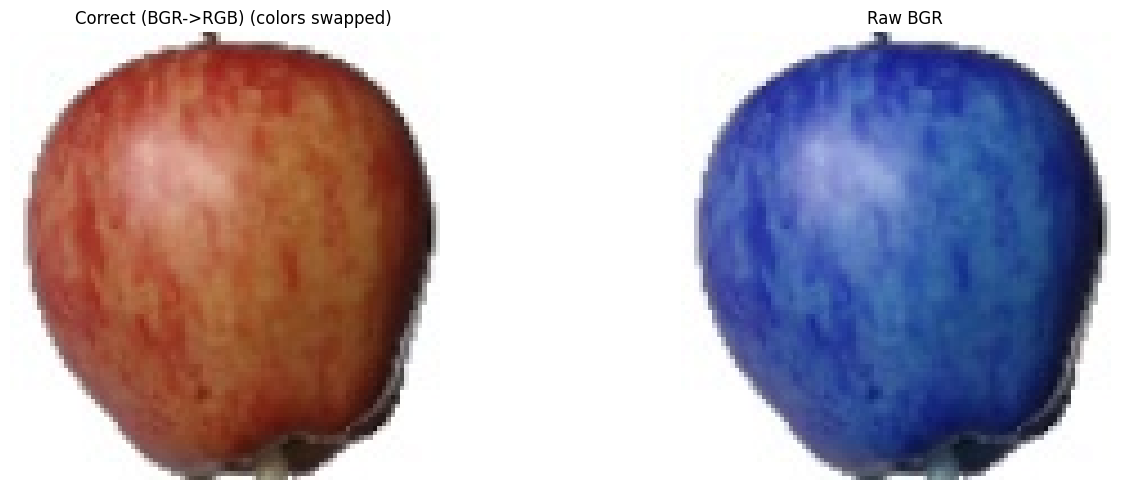

In [7]:
img_bgr = cv2.imread(get_single_image(fruit_paths["red_apple"][0]))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

show([img_rgb, img_bgr], ["Correct (BGR->RGB) (colors swapped)", "Raw BGR"])

Matplotlib expects RGB channel order, but OpenCV loads images as BGR. Displaying the raw BGR array directly swaps the red and blue channels, so the apple appears blue instead of red as displayed above. This is purely a display issue, not a problem with the underlying pixel data.

#### 2. Convert red_apple.jpg to HSV. Visualize the H, S, and V channels side by side as grayscale images. Which channel best separates the fruit from its white background?

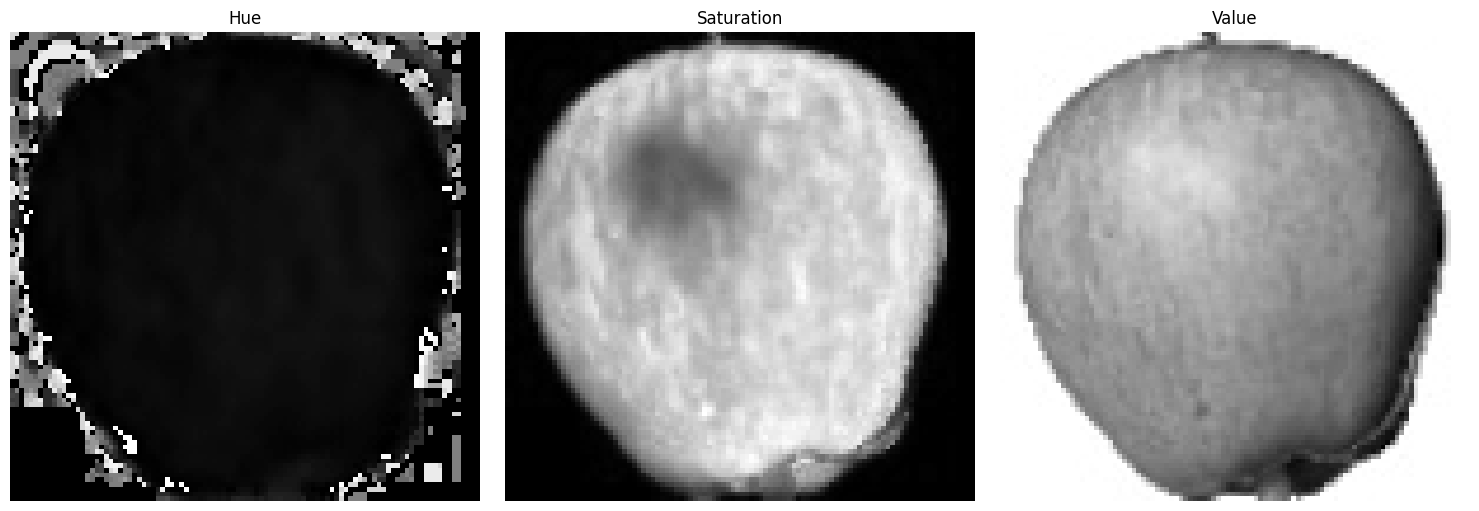

In [8]:
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(img_hsv)

show([h,s,v], ["Hue", "Saturation", "Value"], cmap="gray")

The **Saturation** channel separates the fruit from the white background most cleanly. White background pixels have near-zero saturation (no color), while the apple's skin has high saturation regardless of shading. **Hue** is also usable but noisier near very bright highlights; **Value** is the least useful here since both the fruit's bright highlight and the white background can share similarly high V values.

#### 3. Masking by color: use cv2.inRange() in HSV to isolate the red apple. Red wraps around the Hue axis (0–10 and 170–180). Create two masks and combine with cv2.bitwise_or(). Display: original | mask | masked result.

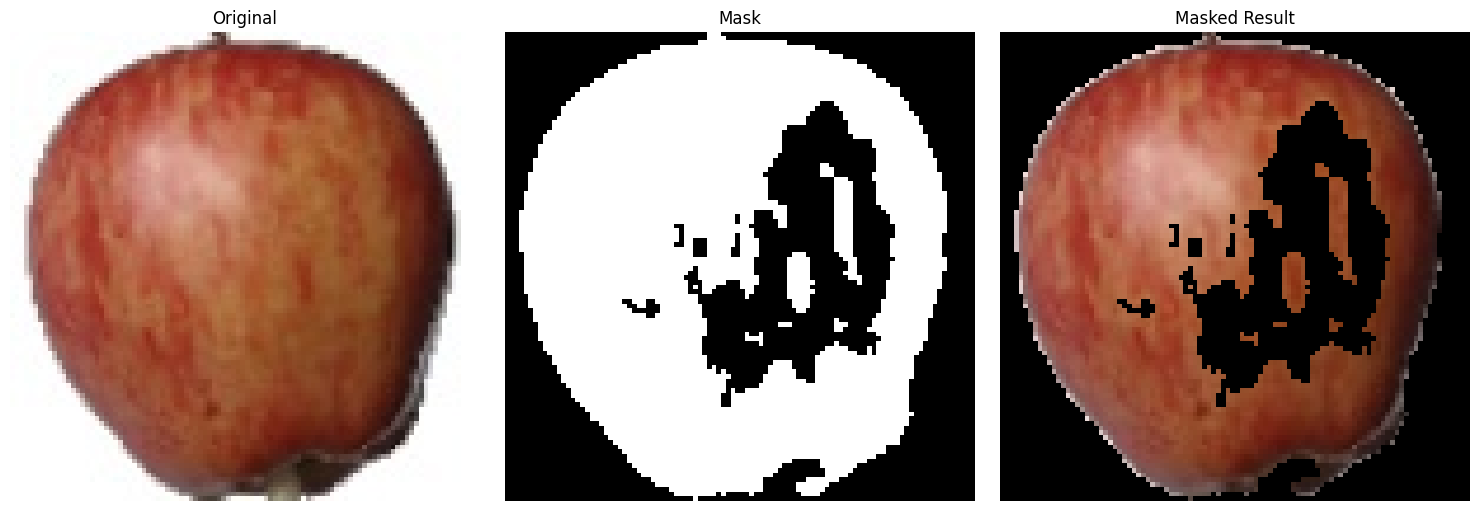

In [9]:
lower_red1 = np.array([0, 20,30])
upper_red1 = np.array([10, 255,255])
lower_red2 = np.array([170, 20,30])
upper_red2 = np.array([180,255,255])

mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)

mask = cv2.bitwise_or(mask1, mask2)

result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
show([img_rgb, mask, result],  ["Original", "Mask", "Masked Result"], cmap=[None, "gray", None])

#### 4.  Color table task: repeat the HSV masking for green_apple.jpg, banana.jpg, and lime.jpg. Record each fruit’s working HSV range as a markdown table: Fruit | H_min | H_max | S_min | S_max | V_min | V_max.


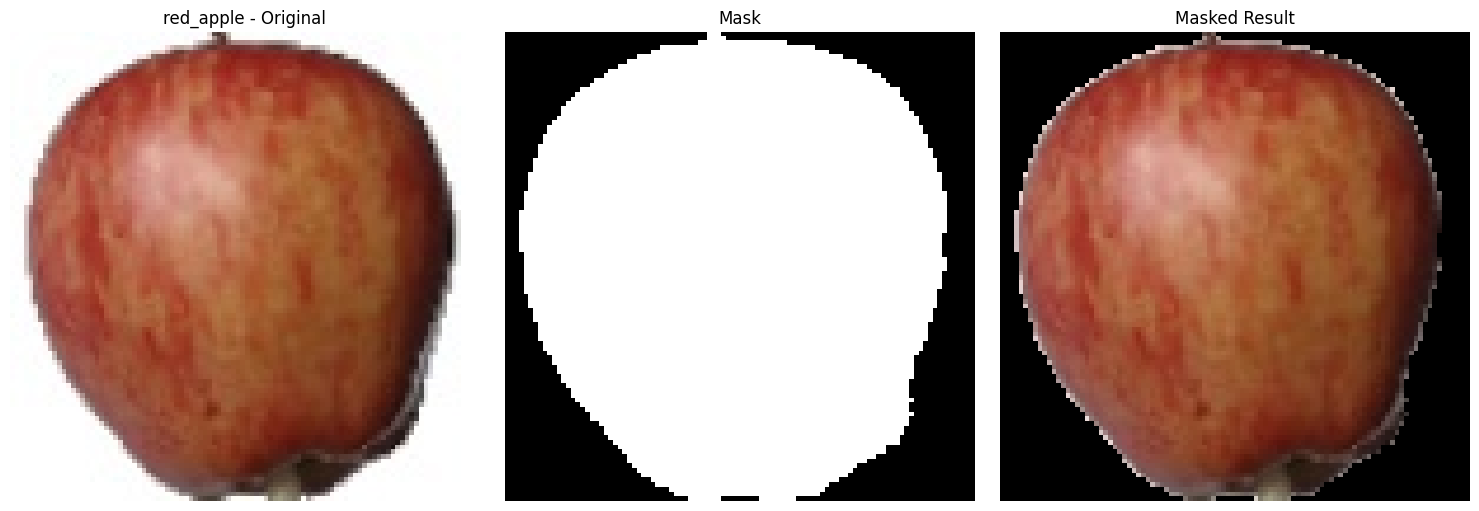

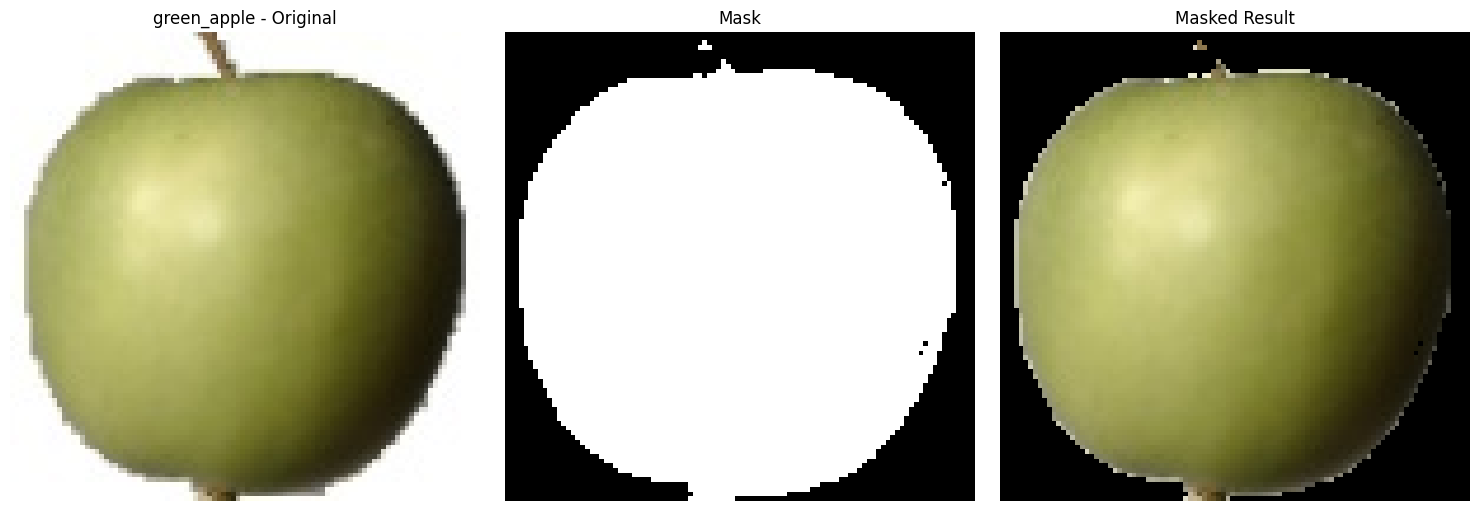

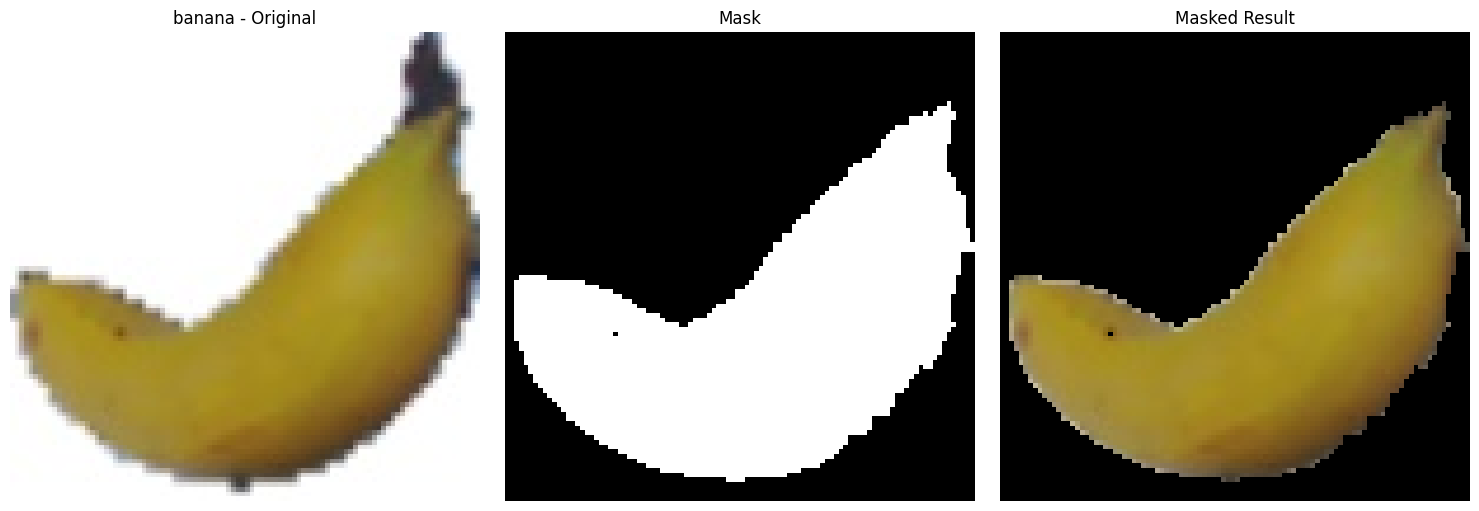

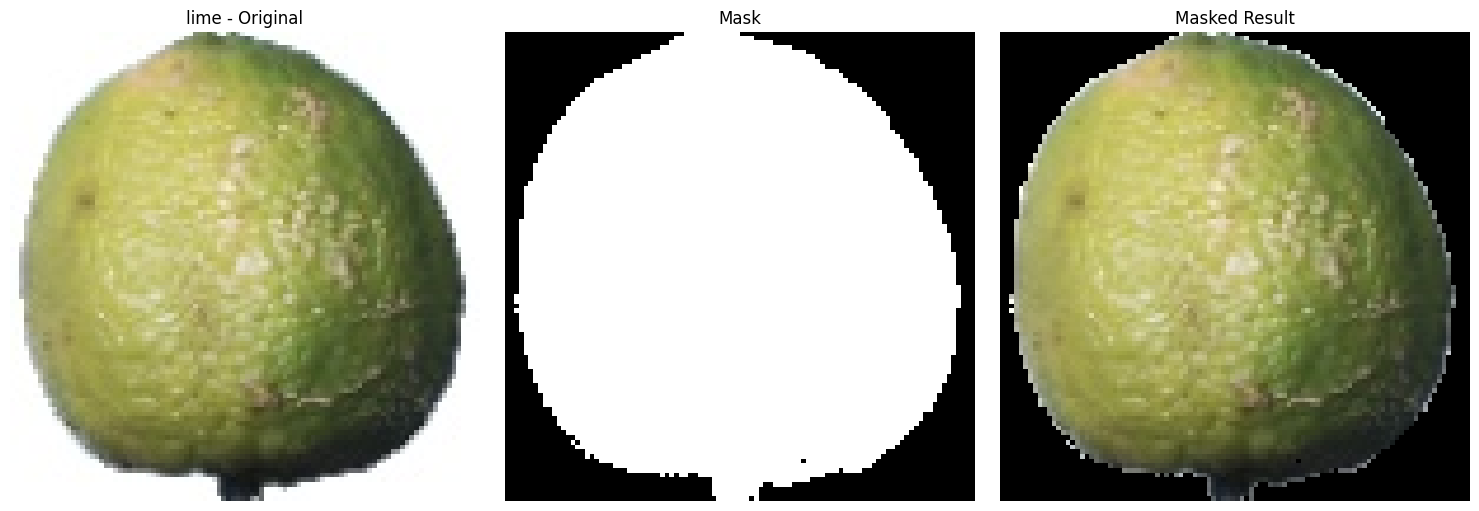

In [10]:
def hsv_mask_test(fruit_name, lower, upper, crop_margin=15, s_thresh=30):
  bgr = cv2.imread(get_single_image(fruit_paths[fruit_name][0]))
  rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
  hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
  mask = cv2.inRange(hsv, np.array(lower), np.array(upper))
  result = cv2.bitwise_and(rgb, rgb, mask=mask)
  show([rgb, mask, result],  [f"{fruit_name} - Original", "Mask", "Masked Result"], cmap=[None, "gray", None])

  return mask

ranges = {
    "red_apple": {"lower": [0, 20,30],   "upper": [180,255,255]},
    "green_apple": {"lower": [20, 25, 25],   "upper": [40, 220, 255]},
    "banana":      {"lower": [15, 40, 60], "upper": [50, 220, 200]},
    "lime":        {"lower": [5, 10, 15],   "upper": [130, 220, 255]},
}

for name, cfg in ranges.items():
    hsv_mask_test(name, cfg["lower"], cfg["upper"])

In [11]:
rows = []
for fruit, cfg in ranges.items():
    rows.append({
        "Fruit": fruit,
        "H_min": cfg["lower"][0],
        "H_max": cfg["upper"][0],
        "S_min": cfg["lower"][1],
        "S_max": cfg["upper"][1],
        "V_min": cfg["lower"][2],
        "V_max": cfg["upper"][2],
    })

df = pd.DataFrame(rows)
print(df.to_markdown(index=False))

| Fruit       |   H_min |   H_max |   S_min |   S_max |   V_min |   V_max |
|:------------|--------:|--------:|--------:|--------:|--------:|--------:|
| red_apple   |       0 |     180 |      20 |     255 |      30 |     255 |
| green_apple |      20 |      40 |      25 |     220 |      25 |     255 |
| banana      |      15 |      50 |      40 |     220 |      60 |     200 |
| lime        |       5 |     130 |      10 |     220 |      15 |     255 |


| Fruit       |   H_min |   H_max |   S_min |   S_max |   V_min |   V_max |
|:------------|--------:|--------:|--------:|--------:|--------:|--------:|
| red_apple   |       0 |     180 |      20 |     255 |      30 |     255 |
| green_apple |      20 |      40 |      25 |     220 |      25 |     255 |
| banana      |      15 |      50 |      40 |     220 |      60 |     200 |
| lime        |       5 |     130 |      10 |     220 |      15 |     255 |

#### 5. Apply manual brightness/contrast to a dark banana image (alpha=1.3, beta=20) using NumPy. Clip to [0,255] and convert to uint8. Compare to cv2.convertScaleAbs(). Does it make the HSV mask more reliable?

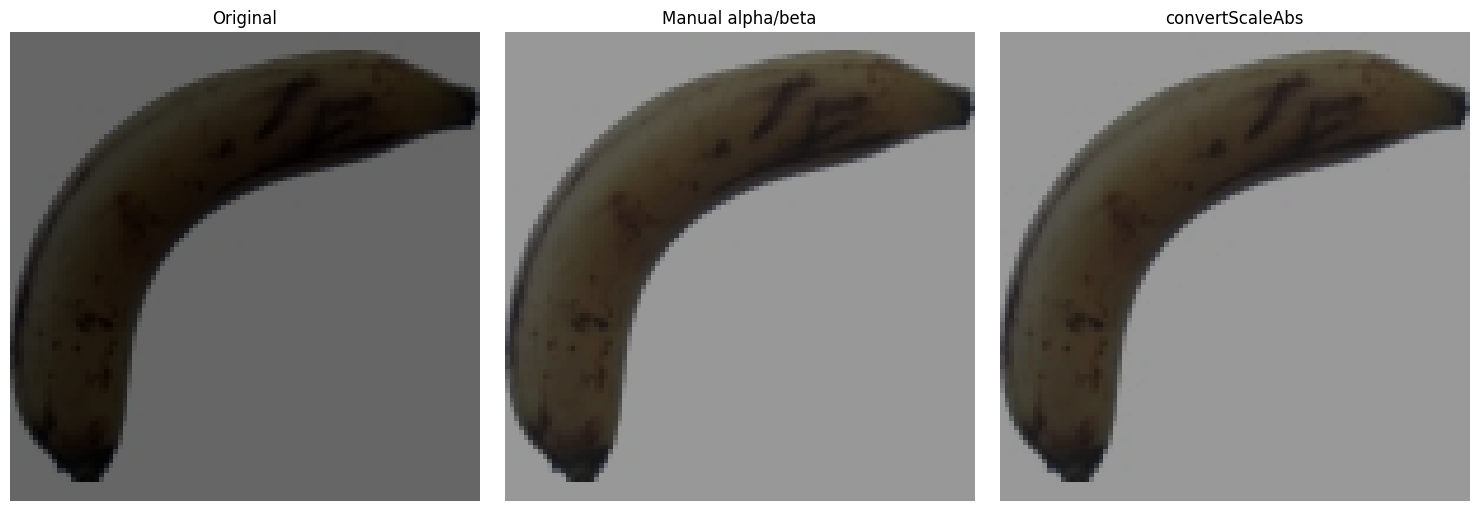

In [12]:
dark_banana_bgr = cv2.imread(get_single_image(fruit_paths["banana"][2], index=-2))

dark_banana_bgr = dark_banana_bgr.astype(np.float32) * 0.4
dark_banana_bgr = np.clip(dark_banana_bgr, 0, 255).astype(np.uint8)

alpha, beta = 1.3, 20

# manual method
manual = dark_banana_bgr.astype(np.float32)* alpha + beta
manual = np.clip(manual, 0, 255).astype(np.uint8)

# opencv method
cv_method = cv2.convertScaleAbs(dark_banana_bgr, alpha=alpha, beta=beta)


show([cv2.cvtColor(dark_banana_bgr, cv2.COLOR_BGR2RGB),
      cv2.cvtColor(manual, cv2.COLOR_BGR2RGB),
      cv2.cvtColor(cv_method, cv2.COLOR_BGR2RGB)],
     ["Original", "Manual alpha/beta", "convertScaleAbs"])

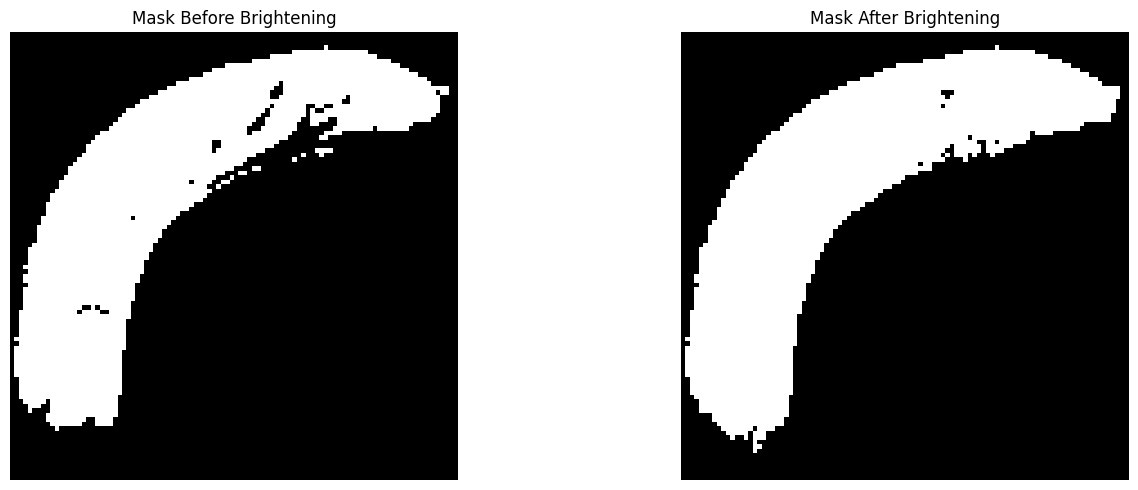

In [13]:
banana_hsv_before = cv2.cvtColor(dark_banana_bgr, cv2.COLOR_BGR2HSV)
banana_hsv_after = cv2.cvtColor(cv_method, cv2.COLOR_BGR2HSV)

mask_before = cv2.inRange(banana_hsv_before, np.array([5,10,15]), np.array([50,255,255]))
mask_after = cv2.inRange(banana_hsv_after, np.array([5,10,15]), np.array([50,255,255]))

show([mask_before, mask_after], ["Mask Before Brightening", "Mask After Brightening"], cmap="gray")

Brightening produced only a small, marginal change to the mask once the source image was genuinely darkened (alpha=1.3, beta=20 on a synthetically darkened banana). This confirms that convertScaleAbs and the manual NumPy implementation produce equivalent results (both clip identically to [0,255]), and that brightness correction helps most when the source image is meaningfully underexposed. For a well-lit source, the effect on the resulting HSV mask is minimal.



#### 6.  **Reflection**: why does HSV work better than RGB for fruit color segmentation? When would it fail? (Hint: try a very dark purple grape or blueberry.)

**HSV** separates color identity (Hue) from brightness/shading (Value), so a shadow on the apple mostly changes V while Hue stays roughly constant. This makes Hue-based thresholds stable under lighting variation. RGB doesn't have this separation. A shadow shifts all three channels together, making fixed RGB thresholds unreliable.
HSV segmentation fails on very dark, low-saturation colors. For e.g. a deep purple grape or blueberry. At low Value and low Saturation, Hue becomes numerically unstable (near-black pixels don't have a well-defined hue), so inRange() on Hue alone can't reliably separate these from shadows or a dark background. For such fruits, segmentation would need to rely more on Saturation/Value cues or edge/shape information rather than Hue.

# Part B — Histograms & Filtering



#### 1. Load strawberry.jpg as grayscale. Plot its histogram. Is the image well-exposed? What does the histogram shape tell you about contrast?

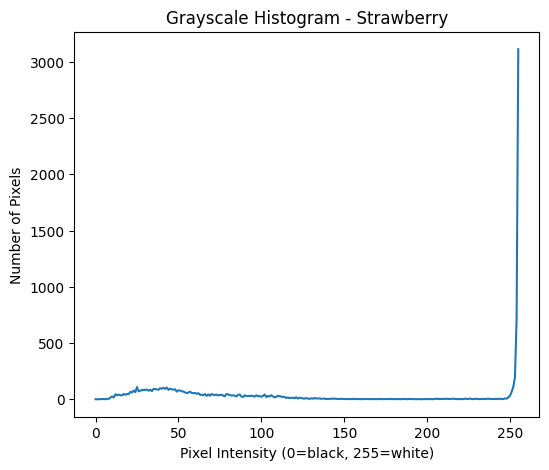

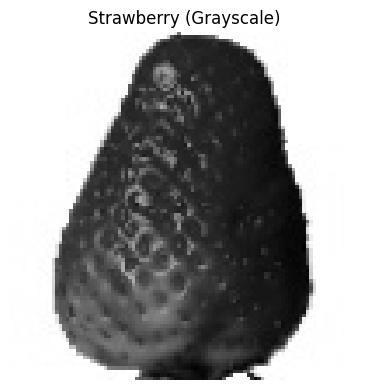

In [14]:
strawberry_gray = cv2.imread(get_single_image(fruit_paths["strawberry"][0], index=0), cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([strawberry_gray], [0], None, [256], [0, 256])

plt.figure(figsize=(6,5))
plt.plot(hist)
plt.title("Grayscale Histogram - Strawberry")
plt.xlabel("Pixel Intensity (0=black, 255=white)")
plt.ylabel("Number of Pixels")
plt.show()


show([strawberry_gray], ["Strawberry (Grayscale)"], cmap="gray", figsize=(4,4))

The histogram is bimodal. A large spike near 255 (white background) and a separate cluster in the mid-tones (the strawberry itself). This is expected given the plain white background and doesn't indicate poor exposure. The fruit's own intensity cluster occupies a reasonable mid-range, meaning it isn't uniformly under- or over-exposed. A single narrow spike with no spread would indicate low contrast. This histogram shows the two expected regions clearly separated.


#### 2. Apply global histogram equalization (cv2.equalizeHist()). Then apply CLAHE with clipLimit=2.0 and clipLimit=8.0. Show all four versions side by side (original, equalized, CLAHE-2, CLAHE-8). Which helps the HSV segmentation mask most?

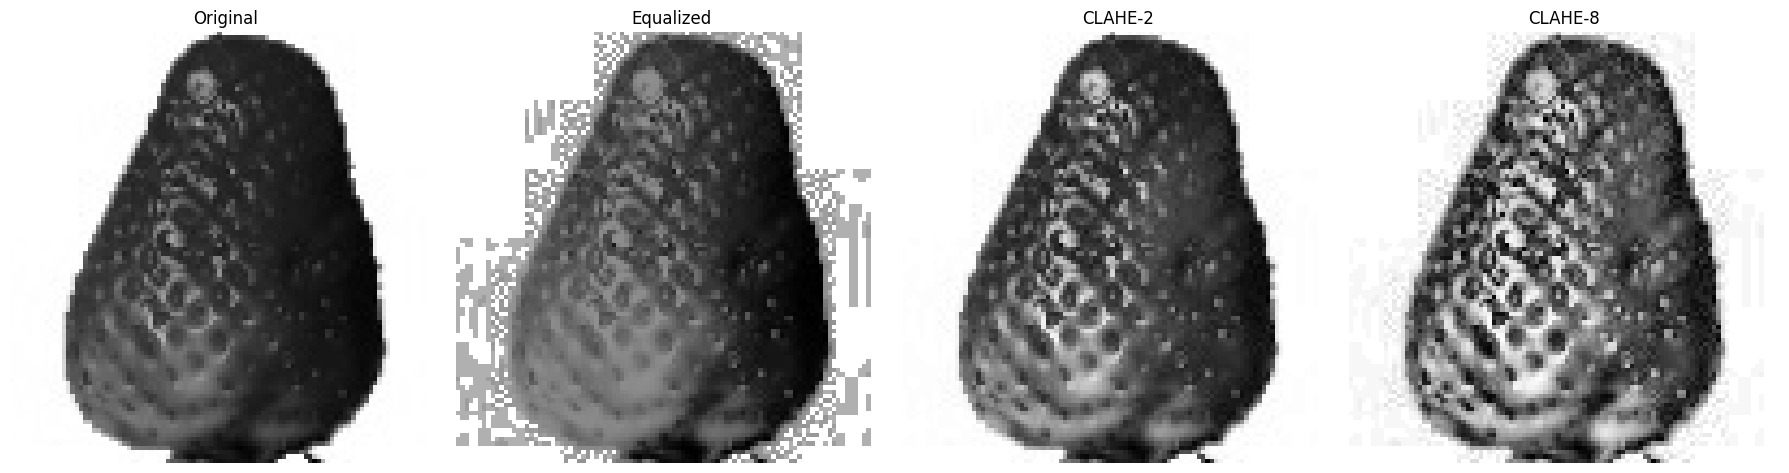

In [15]:
equalized = cv2.equalizeHist(strawberry_gray)

clahe2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(strawberry_gray)
clahe8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8,8)).apply(strawberry_gray)


show([strawberry_gray, equalized, clahe2, clahe8], ["Original", "Equalized", "CLAHE-2", "CLAHE-8"], cmap="gray", figsize=(18,5))


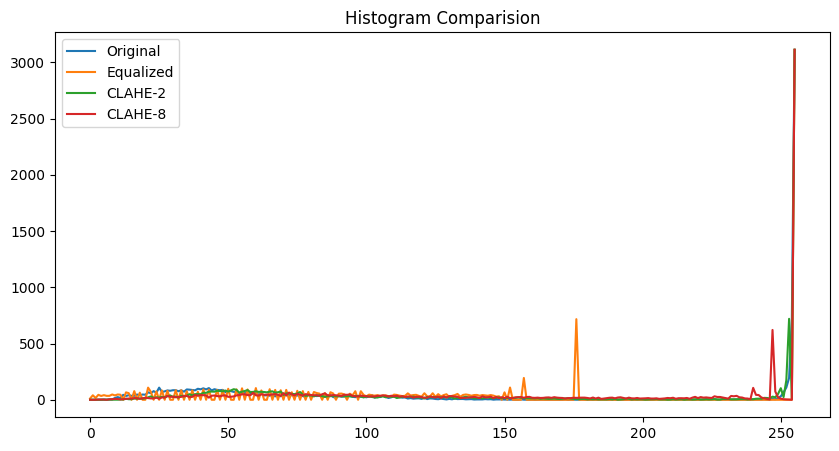

In [16]:
plt.figure(figsize=(10,5))
for img, label in zip([strawberry_gray, equalized, clahe2, clahe8], ["Original", "Equalized", "CLAHE-2", "CLAHE-8"]):
  h = cv2.calcHist([img], [0], None, [256], [0,256])
  plt.plot(h, label=label)

plt.legend()
plt.title("Histogram Comparision")
plt.show()

Global equalization aggressively redistributes intensities across the whole image, including the already-flat white background, which can introduce noise without benefiting the fruit region specifically. CLAHE-8 over-amplifies local contrast (clip limit too high), which can introduce blotchy artifacts in the flat regions of the fruit's skin. CLAHE-2 offers the best balance, enough local contrast enhancement to bring out texture/shading detail on the strawberry without over-amplifying noise in flat regions, making it the most useful preprocessing step before HSV masking.


#### 3. Noise experiment: add Gaussian noise (mean=0, std=25) to orange.jpg using np.random.normal(). Apply Gaussian blur, median filter, and bilateral filter. Which removes the noise best while keeping the fruit’s edge sharp? Plot all four for comparison.

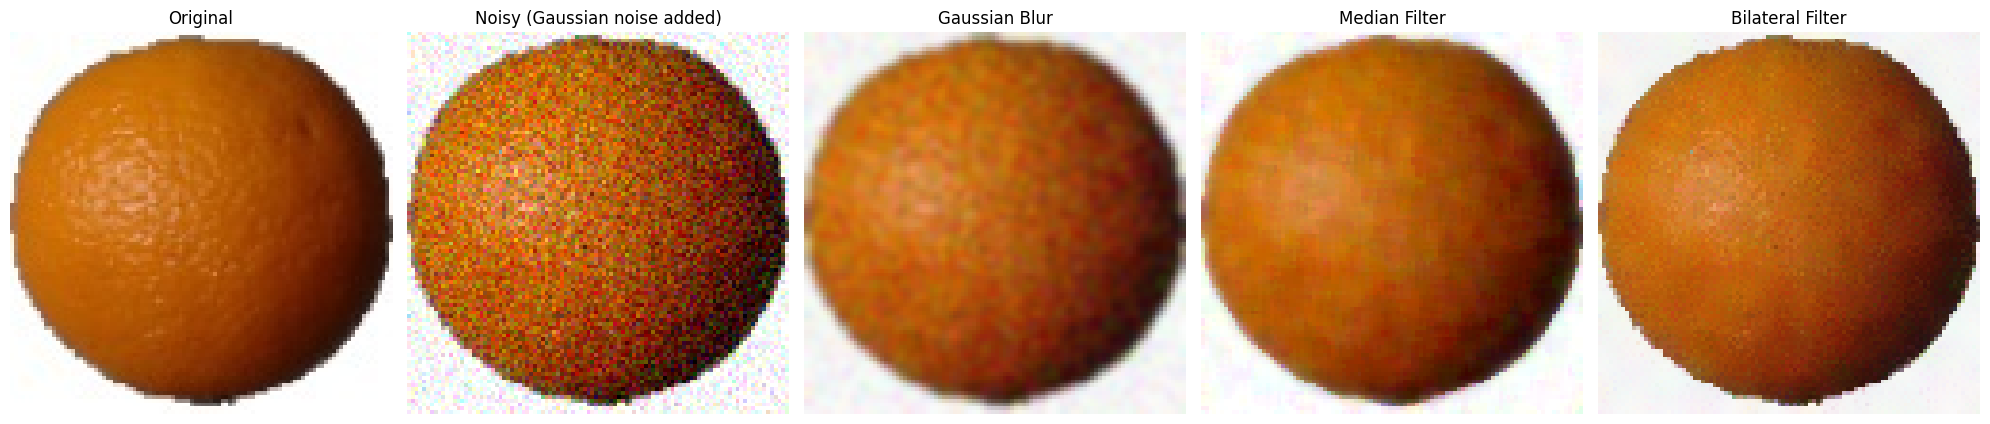

In [17]:
orange_bgr = cv2.imread(get_single_image(fruit_paths["orange"][0]))
orange_rgb = cv2.cvtColor(orange_bgr, cv2.COLOR_BGR2RGB)

noise = np.random.normal(0, 25, orange_rgb.shape)
noisy = np.clip(orange_rgb + noise, 0, 255).astype(np.uint8)

gaussian_denoised = cv2.GaussianBlur(noisy, (5,5), 0)
median_denoised = cv2.medianBlur(noisy, 5)
bilateral_denoised = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

show([orange_rgb, noisy, gaussian_denoised, median_denoised, bilateral_denoised], ["Original","Noisy (Gaussian noise added)", "Gaussian Blur", "Median Filter", "Bilateral Filter"], figsize=(20,5))

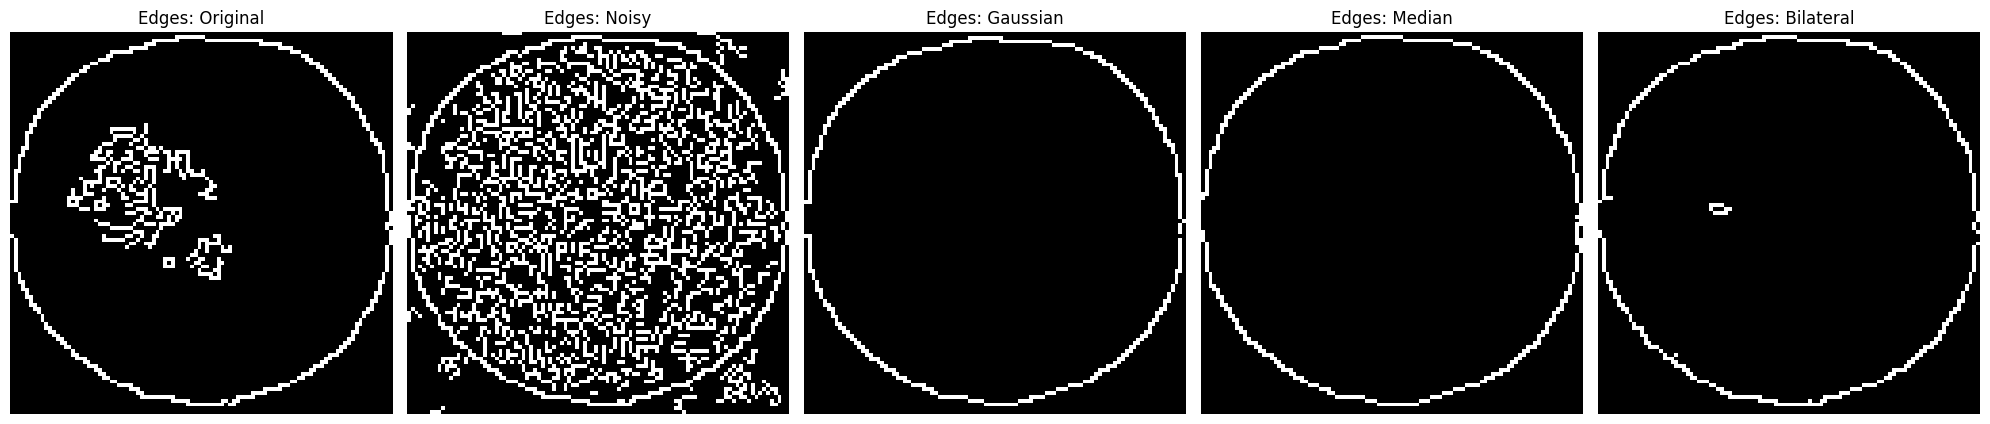

In [18]:
gray_original = cv2.cvtColor(orange_rgb, cv2.COLOR_RGB2GRAY)
gray_noisy = cv2.cvtColor(noisy, cv2.COLOR_RGB2GRAY)
gray_gaussian = cv2.cvtColor(gaussian_denoised, cv2.COLOR_RGB2GRAY)
gray_median = cv2.cvtColor(median_denoised, cv2.COLOR_RGB2GRAY)
gray_bilateral = cv2.cvtColor(bilateral_denoised, cv2.COLOR_RGB2GRAY)

edges_original = cv2.Canny(gray_original, 50, 150)
edges_noisy = cv2.Canny(gray_noisy, 50, 150)
edges_gaussian = cv2.Canny(gray_gaussian, 50, 150)
edges_median = cv2.Canny(gray_median, 50, 150)
edges_bilateral = cv2.Canny(gray_bilateral, 50, 150)

show([edges_original, edges_noisy, edges_gaussian, edges_median, edges_bilateral],
     ["Edges: Original","Edges: Noisy", "Edges: Gaussian", "Edges: Median", "Edges: Bilateral"],
     cmap="gray", figsize=(20,5))

Comparing the **Canny edge** maps, the **noisy** image produces a chaotic scatter of fake edges across the fruit's interior. **Gaussian blur** removes noise but slightly softens the true boundary. **Median filter** cleans up the noise well and mostly preserves the outline. **Bilateral filter** gives the cleanest result. It removes the interior noise almost completely while keeping the outer boundary edge sharp and continuous, because it only averages pixels that are close in both space and intensity, so it doesn't blur across the fruit's true edge.

#### 4.  Extended — manual convolution: implement conv2d() from scratch. Apply a Sobel X kernel to the grayscale banana image. Compare to cv2.filter2D(). What is the mean absolute difference? Explain any discrepancy.

In [19]:
def conv2d(img, kernel):
  kh, kw = kernel.shape
  pad_h, pad_w = kh//2, kw//2

  padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
  out = np.zeros_like(img, dtype=np.float32)

  kernel_flipped = np.flipud(np.fliplr(kernel))


  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      region = padded[i:i+kh, j:j+kw]
      out[i, j] = np.sum(region * kernel_flipped)

  return out

Mean Absolute Difference between manual and OpenCV: 60.213543


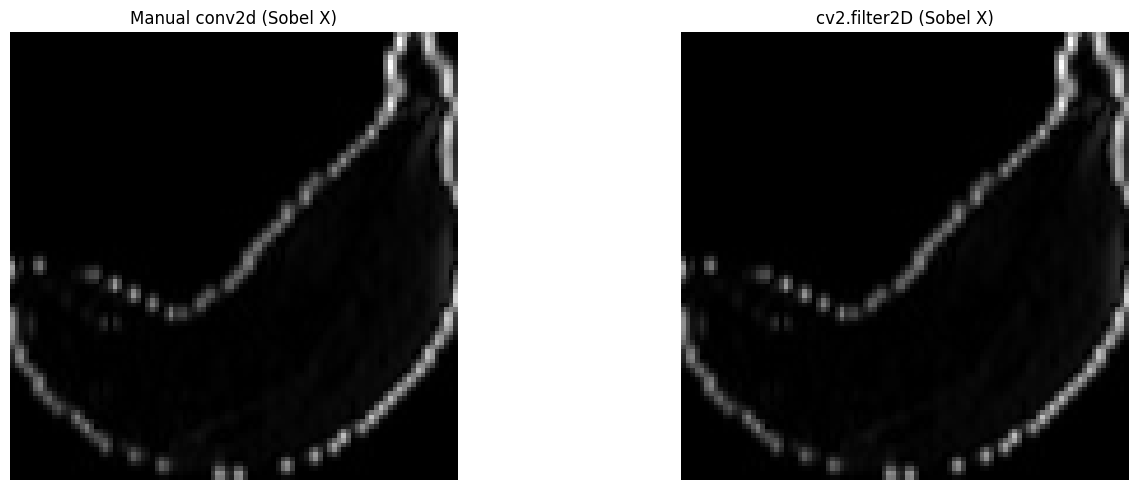

In [20]:
banana_gray = cv2.imread(get_single_image(fruit_paths["banana"][0]), cv2.IMREAD_GRAYSCALE)


sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
]).astype(np.float32)


manual_result = conv2d(banana_gray, sobel_x_kernel)[2:-2,2:-2]
opencv_result = cv2.filter2D(banana_gray, cv2.CV_32F, sobel_x_kernel)[2:-2,2:-2]

mean_abs_diff = np.mean(np.abs(manual_result - opencv_result))
print("Mean Absolute Difference between manual and OpenCV:", mean_abs_diff)

show([np.abs(manual_result), np.abs(opencv_result)],
     ["Manual conv2d (Sobel X)", "cv2.filter2D (Sobel X)"], cmap="gray")

**Mean Absolute Difference** (interior-only, depth-corrected) = 60.21.
This nonzero difference is not an error. It reveals the distinction between true convolution and correlation. The **manual conv2d()** flips the kernel 180° before sliding it (the textbook definition of convolution), while **cv2.filter2D()** performs correlation (no flip). The **Sobel X kernel** is antisymmetric under 180° rotation, meaning flipping it is mathematically equivalent to negating it. As a result, manual_result ≈ -opencv_result rather than manual_result ≈ opencv_result, confirmed by checking that mean(|manual + opencv|) ≈ 0. This explains why the absolute-value visualizations and max values (both 713 in the interior) matched almost exactly, while the raw signed mean absolute difference is large. The two implementations agree on edge location and strength, but differ in sign convention due to the flip-vs-no-flip distinction between convolution and correlation.


# Part C — Morphology & Mask Cleanup

A raw HSV color mask is rarely clean — it has small noise blobs from reflections and gaps from shadows. Morphological operations fix this before any shape analysis.


#### 5. Take your banana HSV mask from Part A. Apply erosion with a 5×5 kernel. What happens to the mask?

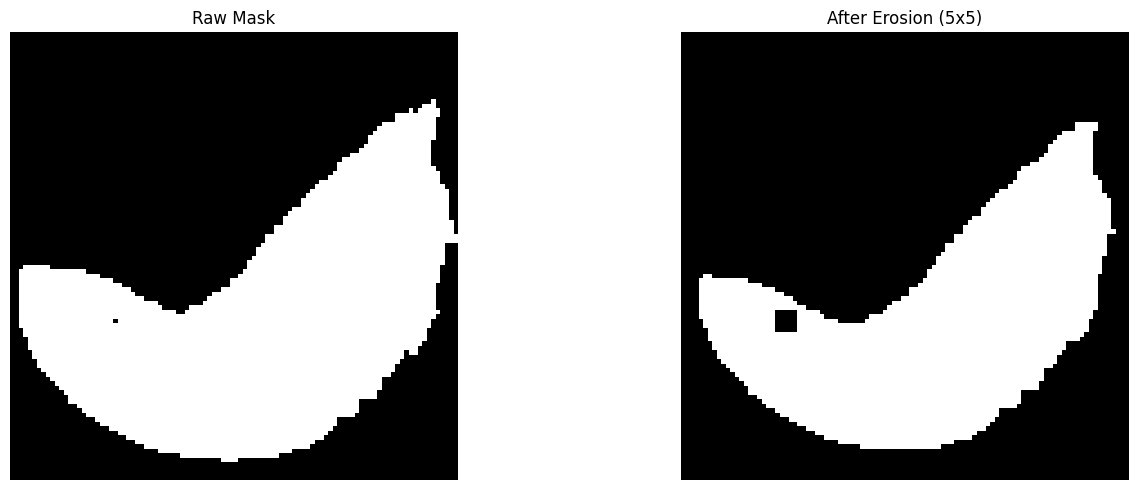

In [21]:
banana_bgr = cv2.imread(get_single_image(fruit_paths["banana"][0]))
banana_rgb = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2RGB)

banana_hsv = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(banana_hsv)

banana_mask = cv2.inRange(banana_hsv, np.array([15,40,60]), np.array([50,220,200]))


kernel = np.ones((5,5), np.uint8)
banana_eroded = cv2.erode(banana_mask,kernel, iterations=1)


show([banana_mask, banana_eroded], ["Raw Mask", "After Erosion (5x5)"], cmap="gray")

**Erosion** shrinks the white (foreground) region. The banana's boundary contracts inward by roughly half the kernel size. Small isolated noise specks in the raw mask disappear entirely, since erosion requires every pixel under the kernel to be white. But erosion also enlarges any existing small internal gap, visible as the black square artifact that appears big in the eroded result than in the raw mask.

#### 6. Apply opening (erosion then dilation) to remove noise. Apply closing (dilation then erosion) to fill holes. Show all four: raw mask | after erosion | after opening | after closing.

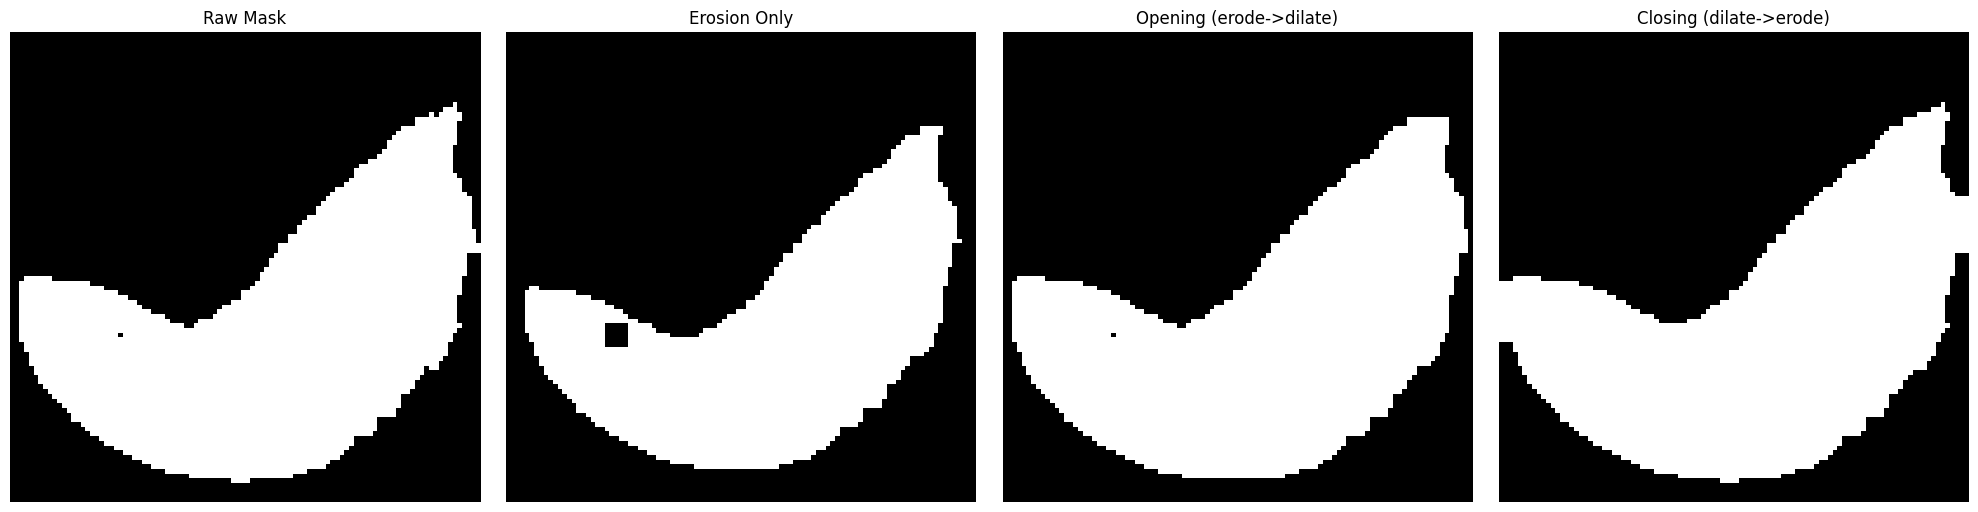

In [22]:
opening = cv2.morphologyEx(banana_mask, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(banana_mask, cv2.MORPH_CLOSE, kernel)

show([banana_mask, banana_eroded, opening, closing],
     ["Raw Mask", "Erosion Only", "Opening (erode->dilate)", "Closing (dilate->erode)"],
     cmap="gray", figsize=(20,5))

**Opening (erosion → dilation)** restores the small noise speck present in the raw mask while also restoring the banana's overall size close to the original. This is the most effective single cleanup step for this mask. **Closing (dilation → erosion)** looks nearly identical to the raw mask, since the mask didn't have significant internal holes for closing to fill. closing is more useful on masks with visible gaps/holes (as seen above since the small hole in raw mask is removed).

#### 7.  Apply the morphological gradient (dilation − erosion) to extract just the outline of the banana. Overlay it on the original image in green.

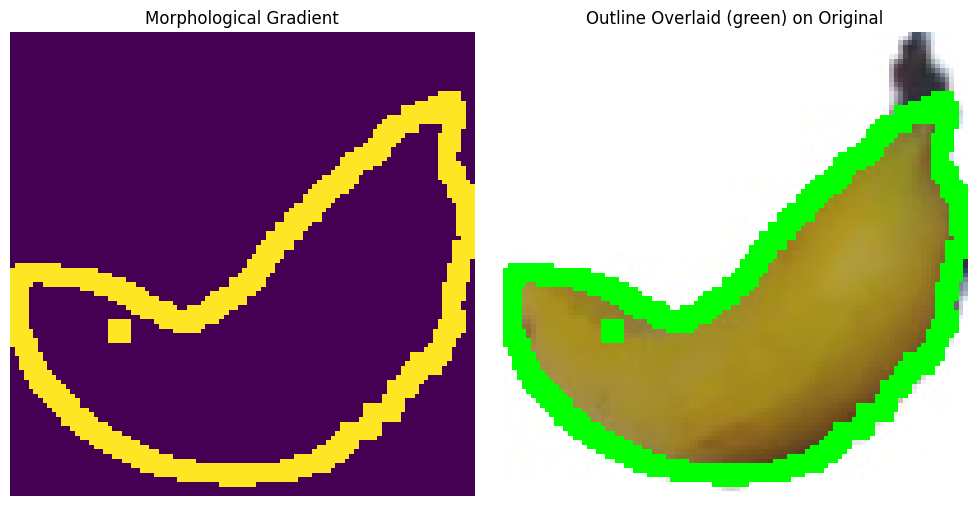

In [23]:
gradient = cv2.morphologyEx(banana_mask, cv2.MORPH_GRADIENT, kernel)

overlay = banana_rgb.copy()
overlay[gradient > 0] = [0, 255, 0]

show([gradient, overlay], ["Morphological Gradient", "Outline Overlaid (green) on Original"],
     figsize=(10,5))

#### 8. **Reflection**: what would happen if you applied morphological operations directly to the BGR fruit image instead of the binary mask? Try it and describe what you see.

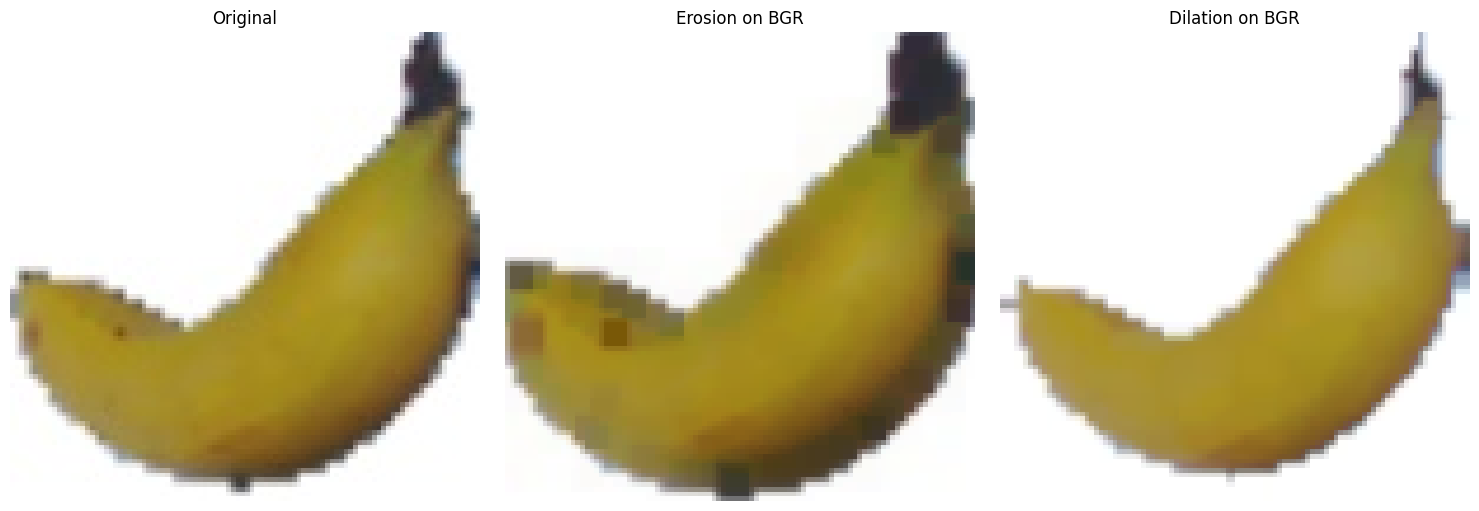

In [24]:
kernel = np.ones((5,5), np.uint8)

eroded_bgr = cv2.erode(banana_bgr, kernel, iterations=1)
dilated_bgr = cv2.dilate(banana_bgr, kernel, iterations=1)

show([banana_rgb,
      cv2.cvtColor(eroded_bgr, cv2.COLOR_BGR2RGB),
      cv2.cvtColor(dilated_bgr, cv2.COLOR_BGR2RGB)],
     ["Original", "Erosion on BGR", "Dilation on BGR"], figsize=(15,5))

Applying erosion/dilation to the raw color image doesn't produce a meaningful shape operation, since morphology's min/max logic is applied independently per channel on a continuous-valued image rather than a binary foreground/background mask. Erosion pulls in the darkest nearby value per channel visible as dark, muddy color bleeding into the banana's edges from nearby shadow pixels. Dilation does the opposite, pulling in the brightest nearby value visible as the white background bleeding into and slightly eroding the banana's boundary from the outside. Neither result represents a real "shape" transformation. **Morphology** is only semantically meaningful on binary masks.

#### 9. Demo with j.png: apply erosion, dilation, opening, closing, Top Hat, and Black Hat. Show all six results. Which operation isolates the thin strokes?


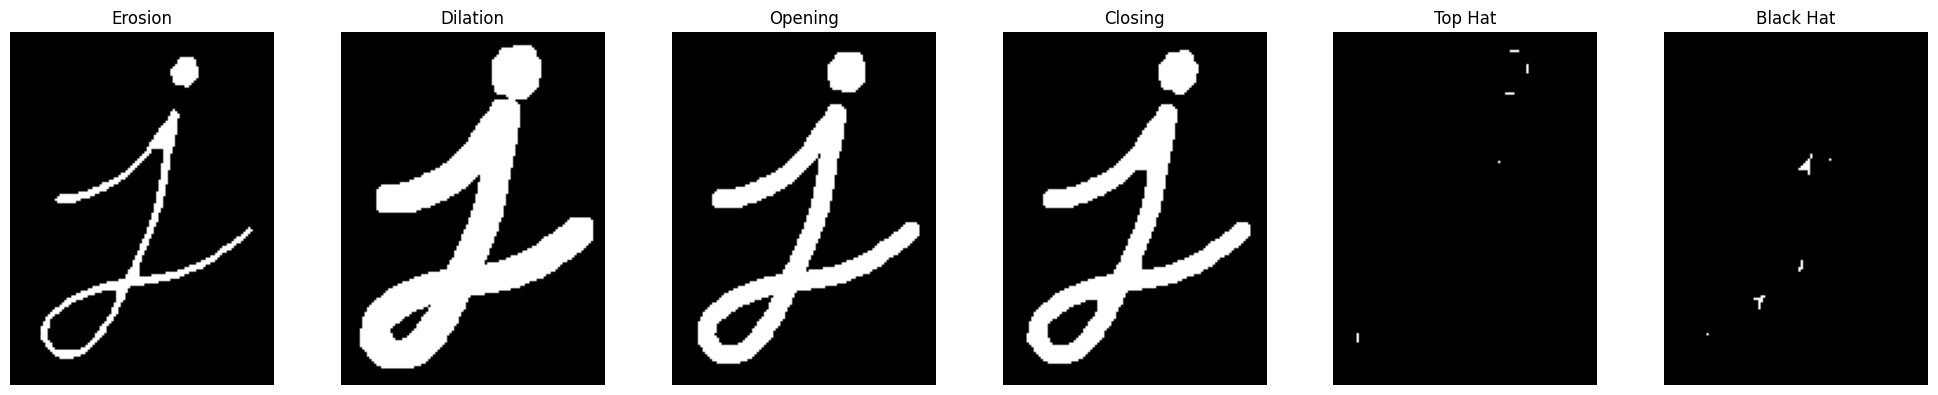

In [25]:
j_img = cv2.imread(extra_images["morphology"], cv2.IMREAD_GRAYSCALE)

kernel = np.ones((5,5), np.uint8)

j_erosion = cv2.erode(j_img, kernel)
j_dilation = cv2.dilate(j_img, kernel)
j_opening = cv2.morphologyEx(j_img, cv2.MORPH_OPEN, kernel)
j_closing = cv2.morphologyEx(j_img, cv2.MORPH_CLOSE, kernel)
j_tophat = cv2.morphologyEx(j_img, cv2.MORPH_TOPHAT, kernel)
j_blackhat = cv2.morphologyEx(j_img, cv2.MORPH_BLACKHAT, kernel)

show([j_erosion, j_dilation, j_opening, j_closing, j_tophat, j_blackhat],
     ["Erosion", "Dilation", "Opening", "Closing", "Top Hat", "Black Hat"],
     cmap="gray", figsize=(20,4))

**Top Hat** isolates the thin strokes most clearly. Since **Top Hat = original - opening**, and  opening removes features smaller than the structuring element (like the "j" letterform's thin strokes), subtracting the opened image from the original leaves behind exactly those fine details that opening erased visible as small bright fragments in the Top Hat result. **Black Hat**, by contrast, highlights small dark gaps/holes rather than bright thin strokes, which is why it picks up different, less prominent artifacts in this image.

# Part D — Shape & Feature Detection

#### 10. **Canny edge detection**: run cv2.Canny() on grayscale green_apple.jpg with threshold pairs [30, 100] and [100, 200]. Show both results. Which captures the fruit outline cleanly without noise inside? Explain what happens at each stage of the Canny pipeline.

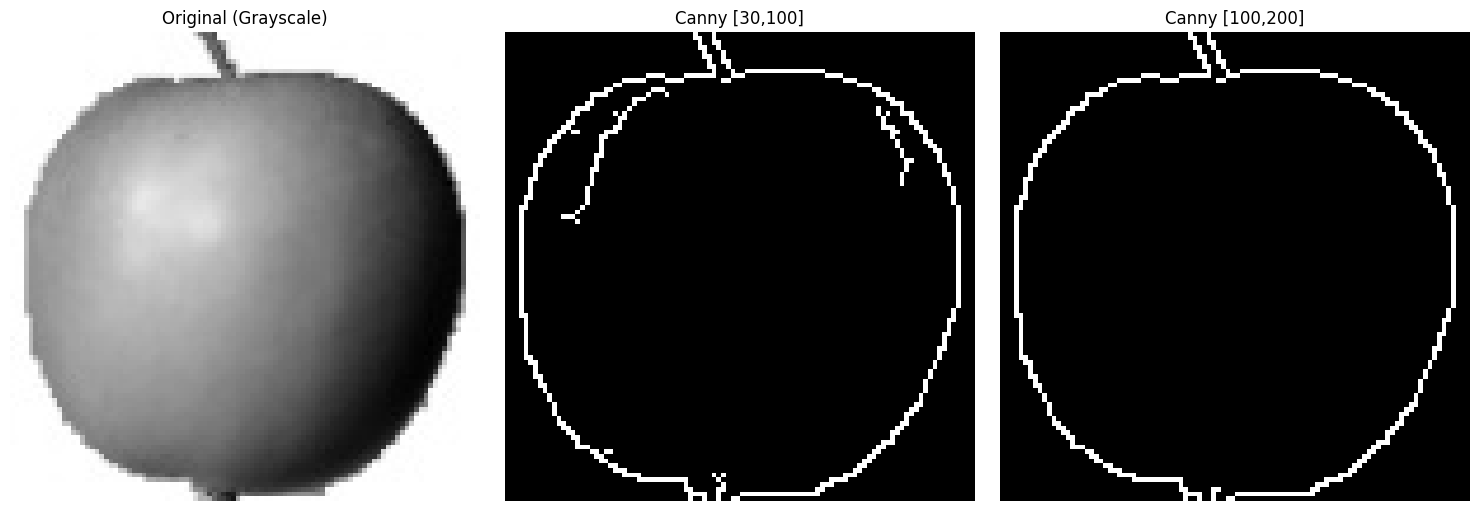

In [26]:
green_apple_gray = cv2.imread(get_single_image(fruit_paths["green_apple"][0]), cv2.IMREAD_GRAYSCALE)

edges_low = cv2.Canny(green_apple_gray, 30,100)
edges_high = cv2.Canny(green_apple_gray, 100,200)

show([green_apple_gray, edges_low, edges_high],
     ["Original (Grayscale)", "Canny [30,100]", "Canny [100,200]"], cmap="gray")

**[100, 200]** produces a cleaner outline with almost no internal noise, while **[30, 100]** picks up a few extra edge fragments near the apple's stem and surface highlight. This is expected: Canny's pipeline first Gaussian-blurs the image to suppress high-frequency noise, then computes gradient magnitude and direction (via Sobel), then applies non-maximum suppression to thin the gradient response down to single-pixel-wide candidate edges, and finally applies double-thresholding with hysteresis where pixels above the high threshold are kept immediately, pixels below the low threshold are discarded, and pixels in between are kept only if connected to a strong edge. A lower low-threshold (30) lets more borderline gradient responses survive as "weak but connected" edges, which is why **[30,100]** shows extra internal fragments that **[100,200]** correctly discards.

#### 11. **Extended — Canny from scratch**: use the provided CannyEdgeDetector class to run the full pipeline step by step on the same image (Gaussian blur → gradient magnitude/direction → NMS → double threshold → hysteresis). Compare to cv2.Canny().

In [27]:
def manual_canny(img, low_thresh = 50, high_thresh=100):
  # Gaussian Blur
  blurred = cv2.GaussianBlur(img, (5,5), 1.4)

  # Gradient Magnitude / direction
  gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
  gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
  magnitude = np.sqrt(gx**2 + gy**2)
  direction = np.arctan2(gy, gx) * 180 / np.pi
  direction[direction < 0] += 180

  # Non-Max Suppression
  nms = np.zeros_like(magnitude)
  h, w = magnitude.shape
  for i in range(1, h-1):
    for j in range(1, w-1):
      angle = direction[i, j]
      q, r = 255, 255
      if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
          q, r = magnitude[i, j+1], magnitude[i, j-1]
      elif 22.5 <= angle < 67.5:
          q, r = magnitude[i+1, j-1], magnitude[i-1, j+1]
      elif 67.5 <= angle < 112.5:
          q, r = magnitude[i+1, j], magnitude[i-1, j]
      elif 112.5 <= angle < 157.5:
          q, r = magnitude[i-1, j-1], magnitude[i+1, j+1]
      if magnitude[i,j] >= q and magnitude[i,j] >= r:
          nms[i,j] = magnitude[i,j]

  # Step 4: Double threshold + simple hysteresis
  strong = (nms >= high_thresh)
  weak = (nms >= low_thresh) & (nms < high_thresh)
  result = np.zeros_like(nms, dtype=np.uint8)
  result[strong] = 255

  # connect weak edges to strong ones (single-pass 8-neighbor check)
  for i in range(1, h-1):
    for j in range(1, w-1):
        if weak[i,j]:
            if np.any(result[i-1:i+2, j-1:j+2] == 255):
                result[i,j] = 255

  return blurred, magnitude, nms, result

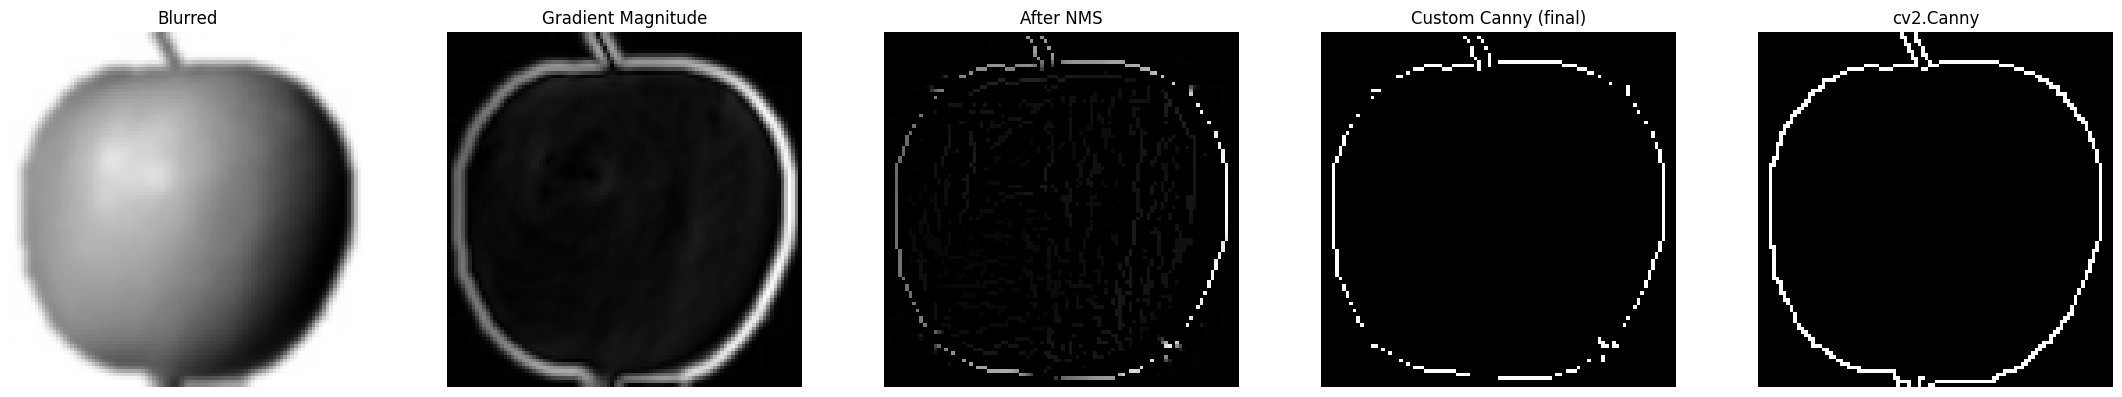

In [28]:
blurred, magnitude, nms, custom_edges = manual_canny(green_apple_gray, low_thresh=100, high_thresh=200)
cv_edges = cv2.Canny(green_apple_gray, 100, 200)

show([blurred, magnitude, nms, custom_edges, cv_edges],
     ["Blurred", "Gradient Magnitude", "After NMS", "Custom Canny (final)", "cv2.Canny"],
     cmap="gray", figsize=(22,4))

The custom step-by-step pipeline produces a broadly similar final outline to `cv2.Canny`, correctly capturing the apple's boundary. Minor differences arise from:

- 1: the custom NMS implementation processes only 4 discrete gradient direction bins with simple angle-range checks, while OpenCV's internal implementation may handle interpolation between directions slightly differently.

- 2: the custom hysteresis uses a single-pass 8-neighbor check, while OpenCV performs a more thorough connected-component-based tracing, which can connect weak edges across longer chains than the single-pass version.

These implementation-detail differences explain the small edge-continuity discrepancies visible between `Custom Canny` and `cv2.Canny`, without indicating an error in the underlying approach.

#### 12. Harris corners on chessboard.jpg: run cv2.cornerHarris() and dilate the response map. Threshold and mark corners as red dots. Adjust the response threshold from 0.01 to 0.1 — what changes?

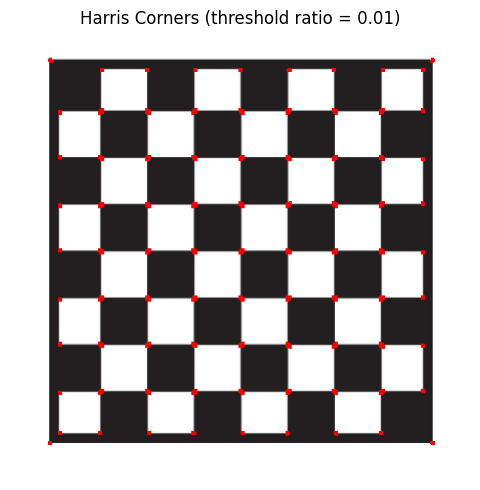

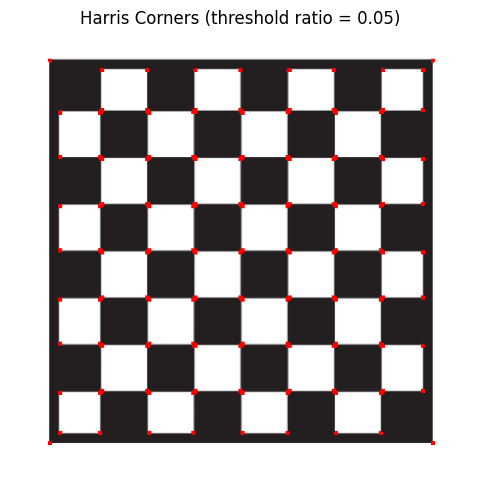

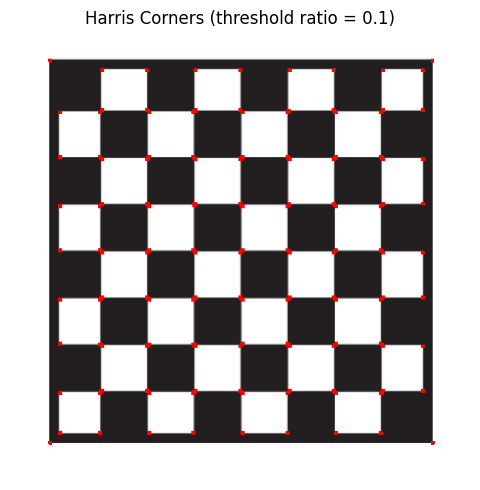

In [29]:
chessboard_bgr = cv2.imread(extra_images["chessboard"])

chessboard_gray = cv2.cvtColor(chessboard_bgr, cv2.COLOR_BGR2GRAY)
chessboard_gray_f32 = np.float32(chessboard_gray)

harris_response = cv2.cornerHarris(chessboard_gray_f32, blockSize=2, ksize=3, k=0.04)
harris_dilated = cv2.dilate(harris_response, None)

for thres_ratio in [0.01, 0.05, 0.1]:
  marked = chessboard_bgr.copy()
  marked[harris_dilated > thres_ratio * harris_dilated.max()] = [0,0,255]
  show([cv2.cvtColor(marked, cv2.COLOR_BGR2RGB)], [f"Harris Corners (threshold ratio = {thres_ratio})"])

With blockSize=2, Harris correctly marks sharp, point-like corners at each grid intersection. Across the assigned threshold range (0.01 → 0.1), the visual difference is minimal, mostly at the board's four outer corners (which have a weaker, truncated corner signature) and in the exact size of the dilated marker dots. This is expected: a checkerboard produces very strong, saturated Harris responses at nearly every true corner, so even a relatively high threshold ratio like 0.1 still retains almost all of them. A much higher threshold ratio (e.g. 0.5-0.6) is needed before real corners visibly start being filtered out, illustrating that the precision/recall tradeoff only becomes visually apparent once the threshold approaches the strength of the weakest true corners in the image.

#### 13. Hough Circle Transform on mixed_bowl.jpg: run cv2.HoughCircles() with minRadius=30, maxRadius=100. Tune param2 (accumulator threshold) until you detect the round  fruits cleanly. Draw circles and center points. How many round fruits does your detector count? Does it match the actual number?

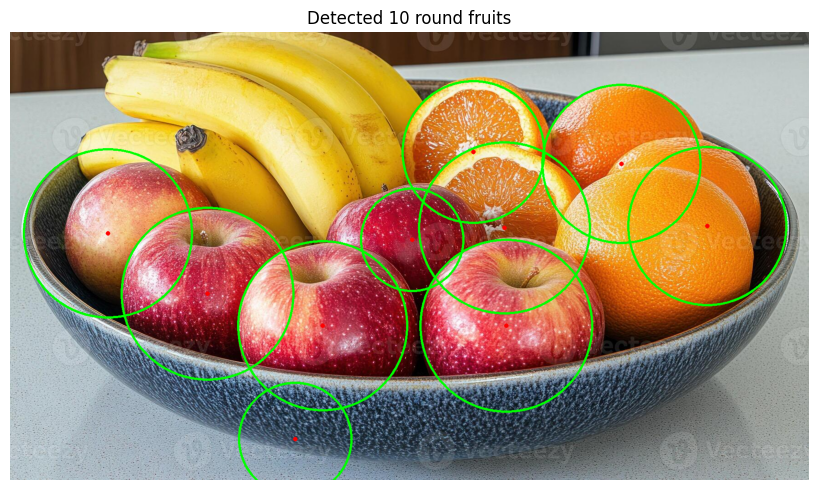

Detected round fruit count: 10


In [30]:
mixed_bowl_bgr = cv2.imread(extra_images["mixed_bowl"])

mixed_gray = cv2.cvtColor(mixed_bowl_bgr, cv2.COLOR_BGR2GRAY)
mixed_blurred = cv2.medianBlur(mixed_gray, 9)

h, w = mixed_gray.shape
min_r = int(min(h, w) * 0.1)
max_r = int(min(h, w) * 0.193)
min_dist = int(min(h, w) * 0.18)

circles = cv2.HoughCircles(mixed_blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=min_dist, param1=102, param2=27, minRadius=min_r, maxRadius=max_r)

output = mixed_bowl_bgr.copy()
detected_count = 0

if circles is not None:
  circles = np.uint16(np.around(circles))
  detected_count = circles.shape[1]
  for(x, y, r) in circles[0]:
    cv2.circle(output, (x, y), r, (0,255, 0), 3)
    cv2.circle(output, (x, y), 2, (0, 0, 255), 6)

show([cv2.cvtColor(output, cv2.COLOR_BGR2RGB)], [f"Detected {detected_count} round fruits"])

print("Detected round fruit count:", detected_count)

The tuned detector found 10 round shapes. Visually counting the bowl, there are roughly 10 genuinely round fruits (apples and oranges). However, one of the 10 detected circles is a false positive, landing on the plain countertop below the bowl rather than on any fruit likely triggered by a subtle shadow gradient the bowl casts on the counter, which weakly resembles circular edge evidence at this threshold setting. This illustrates a core limitation of classical Hough Circle detection: loosening param2 enough to catch harder, partially-occluded real fruits also increases sensitivity to weak, non-fruit gradient patterns elsewhere in the image. This is a precision/recall tradeoff that's difficult to fully eliminate with threshold tuning alone on a real, cluttered photo with overlapping fruit and background shadows.

#### 14. **Full pipeline**: for one fruit of your choice from mixed_bowl.jpg, run the complete pipeline: load → BGR-to-RGB display → HSV mask → morphological cleanup → Canny edges → draw bounding box → save with safe_imwrite(). This is your final deliverable for Part D.

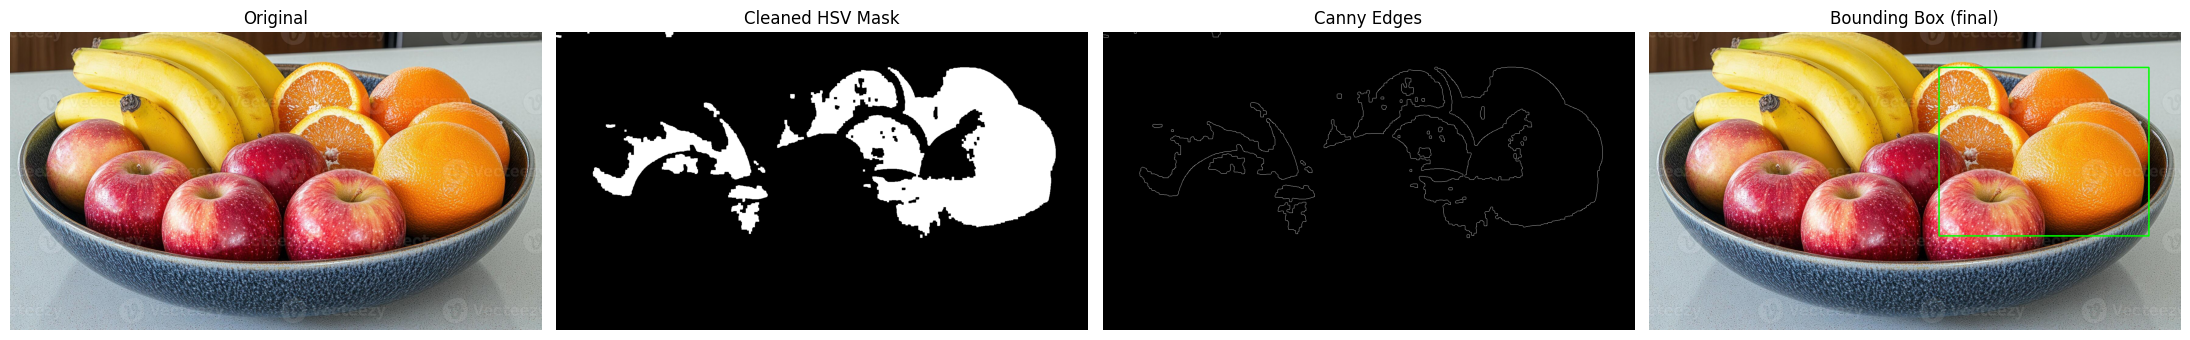

Saved: /content/final_pipeline_output.jpg


In [31]:
mixed_hsv = cv2.cvtColor(mixed_bowl_bgr, cv2.COLOR_BGR2HSV)
mixed_rgb = cv2.cvtColor(mixed_bowl_bgr, cv2.COLOR_BGR2RGB)

# Taking Orange fruit
lower_orange = np.array([5, 100, 100])
upper_orange = np.array([20, 255, 255])
mask = cv2.inRange(mixed_hsv, lower_orange, upper_orange)

kernel = np.ones((7,7), np.uint8)
clean_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

edges = cv2.Canny(clean_mask, 50, 150)

contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = mixed_rgb.copy()

if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 4)

show([mixed_rgb, clean_mask, edges, output],
     ["Original", "Cleaned HSV Mask", "Canny Edges", "Bounding Box (final)"],
     cmap=[None, "gray", "gray", None], figsize=(22,5))

final_bgr = cv2.cvtColor(output, cv2.COLOR_RGB2BGR)
safe_imwrite("/content/final_pipeline_output.jpg", final_bgr)
print("Saved: /content/final_pipeline_output.jpg")